# **1. Perkenalan Dataset**


## Dataset: Predictive Maintenance Dataset AI4I 2020

**Sumber Dataset:** [Kaggle - Predictive Maintenance Dataset AI4I 2020](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/data)

**Deskripsi:**
Dataset ini berisi data sensor mesin industri yang disimulasikan berdasarkan kondisi nyata dari lingkungan manufaktur. Dataset AI4I 2020 Predictive Maintenance terdiri dari 10.000 data point dengan 14 kolom yang mencakup parameter operasional mesin.

**Tujuan:**
Membangun model machine learning untuk memprediksi apakah sebuah mesin industri akan mengalami kegagalan (failure) berdasarkan data sensor dan parameter operasionalnya. Ini merupakan studi kasus **predictive maintenance** yang bertujuan mendeteksi potensi kerusakan mesin sebelum terjadi downtime.

**Jenis Task:** Binary Classification

**Target Prediksi:** `Machine failure`
- **0** = Mesin dalam kondisi normal
- **1** = Mesin mengalami kegagalan

**Fitur yang Digunakan:**
| Fitur | Deskripsi |
|-------|----------|
| Type | Tipe kualitas produk (L, M, H) |
| Air temperature [K] | Suhu udara dalam Kelvin |
| Process temperature [K] | Suhu proses dalam Kelvin |
| Rotational speed [rpm] | Kecepatan rotasi dalam RPM |
| Torque [Nm] | Torsi dalam Newton-meter |
| Tool wear [min] | Keausan alat dalam menit |

**Kolom yang Dihapus:**
- `UDI` — hanya identifier
- `Product ID` — hanya kode produk
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — indikator jenis kegagalan yang menyebabkan data leakage

**Alasan Dataset Cocok untuk Predictive Maintenance:**
Dataset ini merepresentasikan skenario nyata di industri manufaktur di mana sensor mengumpulkan data operasional mesin secara real-time. Dengan menggunakan model prediktif, perusahaan dapat menjadwalkan perawatan mesin secara proaktif, mengurangi downtime, dan menghemat biaya.

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka (library) Python yang dibutuhkan untuk analisis data, visualisasi, dan preprocessing.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

print("Library imported successfully!")

Library imported successfully!


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset dari file CSV. Dataset Predictive Maintenance AI4I 2020 berisi 10.000 data point dengan informasi sensor mesin industri.

In [3]:
# Memuat dataset
df = pd.read_csv('../predictive_maintenance_raw/predictive_maintenance.csv')

# Menampilkan 5 data awal
print("=" * 60)
print("5 DATA AWAL")
print("=" * 60)
df.head()

5 DATA AWAL


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Ukuran dataset
print(f"Ukuran dataset: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Ukuran dataset: (10000, 14)
Jumlah baris: 10000
Jumlah kolom: 14


In [5]:
# Informasi tipe data
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: fl

In [6]:
# Statistik deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe()

STATISTIK DESKRIPTIF


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
# === Cek Missing Values ===
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

MISSING VALUES
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Total missing values: 0


In [8]:
# === Cek Data Duplikat ===
print("=" * 60)
print("DATA DUPLIKAT")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

DATA DUPLIKAT
Jumlah data duplikat: 0


In [9]:
# === Distribusi Target ===
print("=" * 60)
print("DISTRIBUSI TARGET (Machine failure)")
print("=" * 60)
target_dist = df['Machine failure'].value_counts()
print(target_dist)
print(f"\nPersentase kegagalan: {target_dist[1]/len(df)*100:.2f}%")
print(f"Persentase normal: {target_dist[0]/len(df)*100:.2f}%")

DISTRIBUSI TARGET (Machine failure)
Machine failure
0    9661
1     339
Name: count, dtype: int64

Persentase kegagalan: 3.39%
Persentase normal: 96.61%


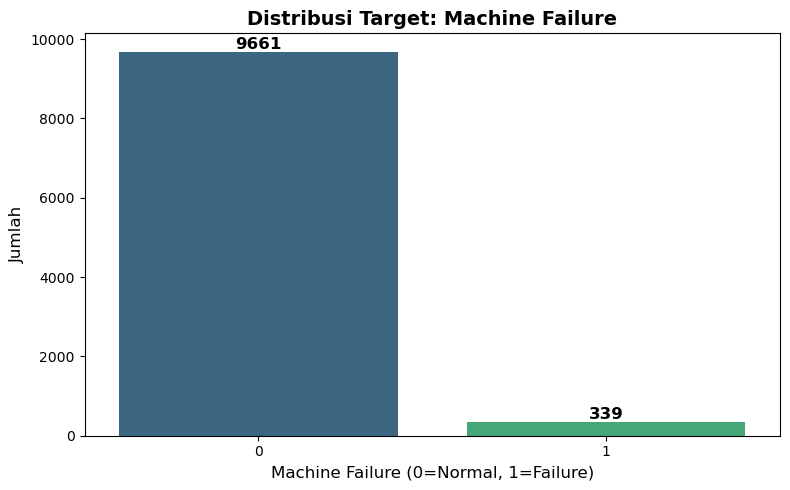

In [10]:
# === Countplot Target ===
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Machine failure', data=df, palette='viridis')
plt.title('Distribusi Target: Machine Failure', fontsize=14, fontweight='bold')
plt.xlabel('Machine Failure (0=Normal, 1=Failure)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Tambahkan label di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretasi:** Dataset menunjukkan adanya **class imbalance** yang signifikan. Jumlah mesin normal (label 0) jauh lebih banyak dibandingkan mesin yang mengalami kegagalan (label 1). Hal ini perlu diperhatikan dalam pemilihan model dan metrik evaluasi.

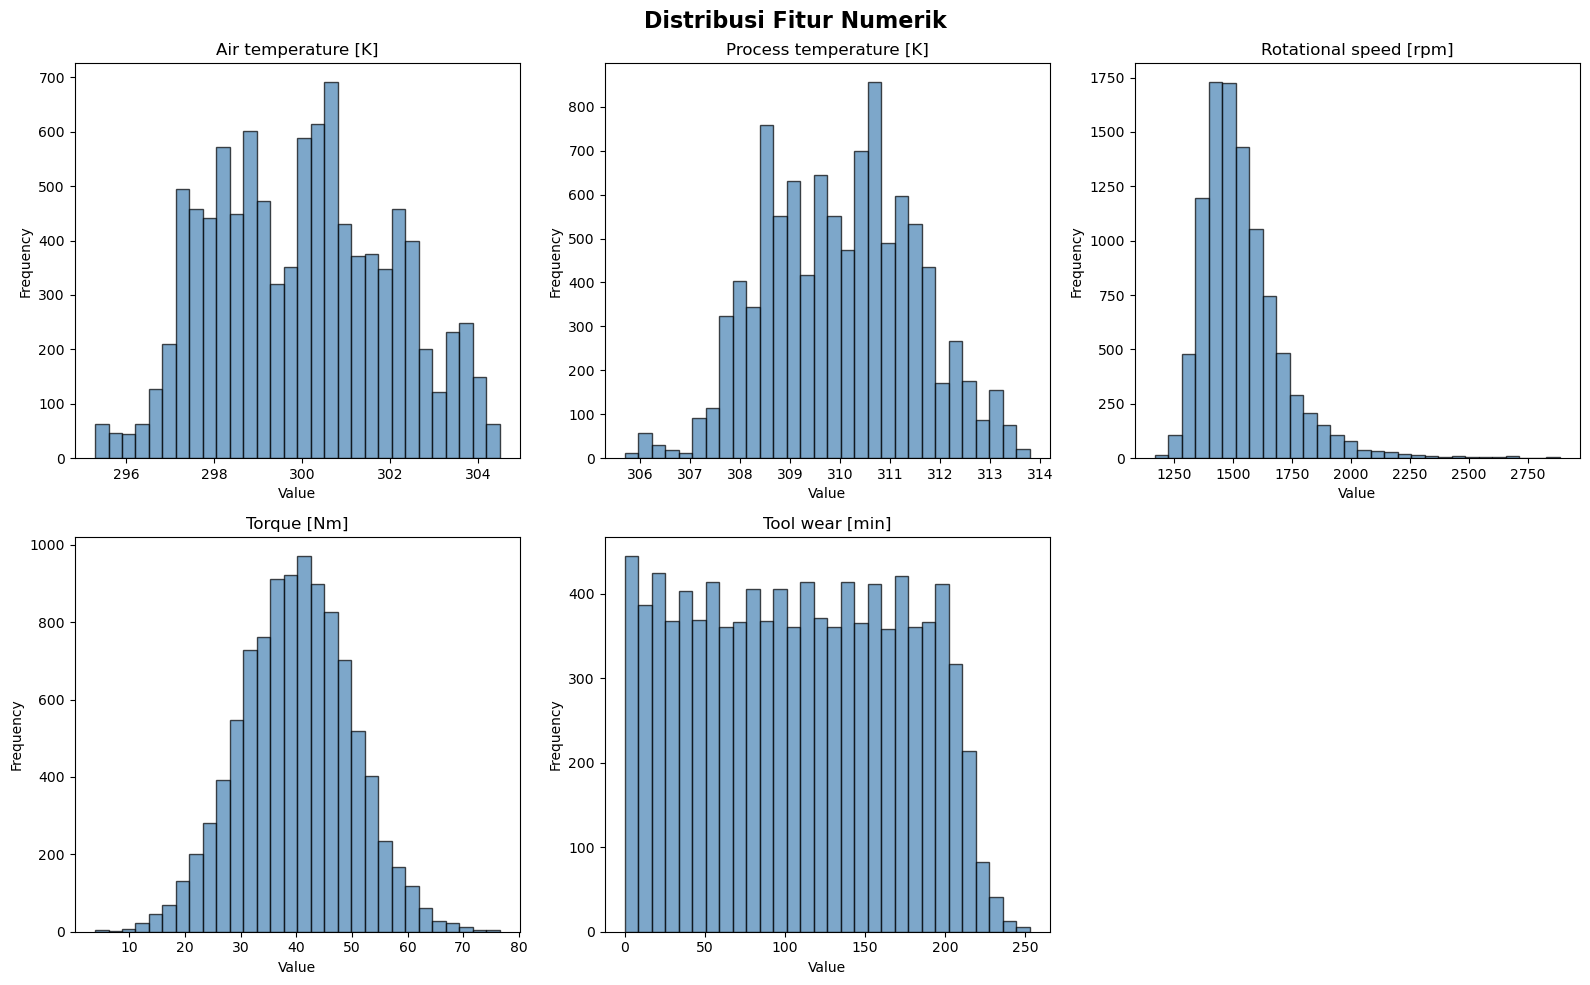

In [11]:
# === Histogram Fitur Numerik ===
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')

for i, feature in enumerate(numerical_features):
    row = i // 3
    col = i % 3
    axes[row, col].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[row, col].set_title(feature, fontsize=12)
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

# Hapus subplot kosong
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretasi Distribusi Fitur Numerik:**
- **Air temperature** dan **Process temperature**: Distribusi mendekati normal.
- **Rotational speed**: Distribusi miring ke kanan (right-skewed), sebagian besar mesin beroperasi di kecepatan tertentu.
- **Torque**: Distribusi mendekati normal dengan beberapa outlier di ujung kanan.
- **Tool wear**: Distribusi relatif uniform, menunjukkan keausan alat terdistribusi merata.

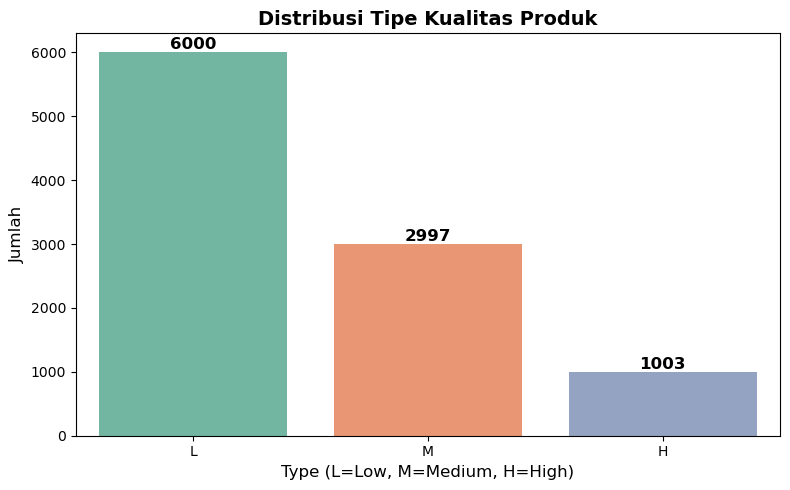


Distribusi Type:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [12]:
# === Countplot Fitur Kategorikal (Type) ===
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Type', data=df, palette='Set2', order=['L', 'M', 'H'])
plt.title('Distribusi Tipe Kualitas Produk', fontsize=14, fontweight='bold')
plt.xlabel('Type (L=Low, M=Medium, H=High)', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Tambahkan label
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDistribusi Type:")
print(df['Type'].value_counts())

**Interpretasi:** Tipe produk didominasi oleh tipe **L (Low quality)** sebesar ~60%, diikuti **M (Medium)** ~30%, dan **H (High)** ~10%. Distribusi ini menunjukkan proporsi kualitas produk yang tidak seimbang.

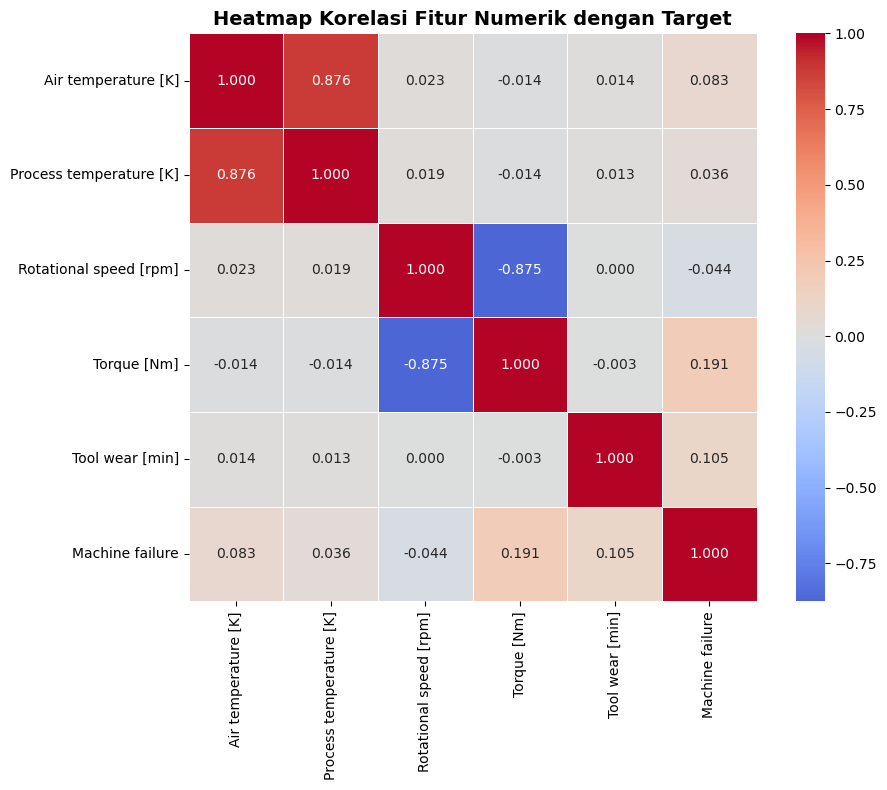

In [13]:
# === Heatmap Korelasi ===
# Pilih kolom numerik termasuk target
corr_columns = numerical_features + ['Machine failure']
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur Numerik dengan Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi Korelasi:**
- Tidak ada fitur yang memiliki korelasi sangat tinggi dengan target `Machine failure`, yang menunjukkan prediksi memerlukan kombinasi beberapa fitur.
- **Torque** dan **Rotational speed** memiliki korelasi negatif satu sama lain, yang masuk akal secara fisika.
- **Air temperature** dan **Process temperature** berkorelasi positif, karena suhu proses dipengaruhi oleh suhu udara.
- Preprocessing dengan scaling diperlukan karena rentang nilai fitur sangat berbeda.

**Kesimpulan EDA:**
1. **Tidak ada missing value** dalam dataset.
2. **Target imbalance**: Kelas kegagalan jauh lebih sedikit dari kelas normal.
3. **Tidak ada data duplikat** (atau sangat sedikit).
4. Fitur numerik memiliki skala yang berbeda-beda, sehingga **StandardScaler** diperlukan.
5. Fitur kategorikal `Type` perlu di-encode menggunakan **OneHotEncoder**.
6. Kolom identifier (UDI, Product ID) dan indikator failure (TWF, HDF, PWF, OSF, RNF) harus dihapus.

# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data untuk mempersiapkan dataset agar siap digunakan untuk training model machine learning.

Tahapan preprocessing:
1. Copy dataframe mentah
2. Hapus kolom yang tidak diperlukan
3. Pisahkan fitur dan target
4. Tentukan kolom numerik dan kategorikal
5. OneHotEncoder untuk kolom Type
6. StandardScaler untuk fitur numerik
7. Train-test split
8. Simpan hasil preprocessing

In [14]:
# === Step 1: Copy dataframe mentah ===
df_clean = df.copy()
print(f"Shape sebelum cleaning: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")

Shape sebelum cleaning: (10000, 14)
Kolom: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [15]:
# === Step 2: Hapus kolom identifier dan data leakage ===
columns_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df_clean.drop(columns=columns_to_drop)

print(f"Kolom yang dihapus: {columns_to_drop}")
print(f"Shape setelah cleaning: {df_clean.shape}")
print(f"Kolom tersisa: {list(df_clean.columns)}")

Kolom yang dihapus: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Shape setelah cleaning: (10000, 7)
Kolom tersisa: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [16]:
# === Step 3: Pisahkan fitur dan target ===
target_column = 'Machine failure'
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print(f"Fitur (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nKolom fitur: {list(X.columns)}")
print(f"\nDistribusi target:\n{y.value_counts()}")

Fitur (X) shape: (10000, 6)
Target (y) shape: (10000,)

Kolom fitur: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Distribusi target:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [17]:
# === Step 4: Tentukan kolom numerik dan kategorikal ===
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
categorical_features = ['Type']

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features (5): ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical features (1): ['Type']


In [18]:
# === Step 5 & 6: ColumnTransformer (OneHotEncoder + StandardScaler) ===
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

print("ColumnTransformer created:")
print(f"  - StandardScaler for: {numerical_features}")
print(f"  - OneHotEncoder (drop='first') for: {categorical_features}")

ColumnTransformer created:
  - StandardScaler for: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
  - OneHotEncoder (drop='first') for: ['Type']


In [19]:
# === Step 7: Train-Test Split ===
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train shape: (8000, 6)
X_test shape: (2000, 6)
y_train shape: (8000,)
y_test shape: (2000,)

y_train distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

y_test distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [20]:
# === Fit dan Transform ===
# Fit pada training data, transform pada keduanya
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Dapatkan nama kolom setelah transformasi
cat_encoder = preprocessor.named_transformers_['cat']
cat_columns = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = numerical_features + cat_columns

print(f"Feature names after preprocessing: {feature_names}")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Feature names after preprocessing: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']
X_train_processed shape: (8000, 7)
X_test_processed shape: (2000, 7)


In [21]:
# === Konversi ke DataFrame ===
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Reset index
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Preprocessed X_train:")
X_train_df.head()

Preprocessed X_train:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,0.0,1.0
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,0.0,1.0
2,0.498092,1.077466,-1.007654,0.558607,0.460870,0.0,1.0
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,1.0,0.0
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,1.0,0.0


In [22]:
# === Step 8: Simpan Hasil Preprocessing ===
output_dir = 'predictive_maintenance_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_df.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test_df.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print("Dataset preprocessing berhasil disimpan!")
print(f"Output directory: {output_dir}")
for f in os.listdir(output_dir):
    fpath = os.path.join(output_dir, f)
    print(f"  {f} ({os.path.getsize(fpath)} bytes)")

Dataset preprocessing berhasil disimpan!
Output directory: predictive_maintenance_preprocessing
  X_test.csv (214287 bytes)
  X_train.csv (856631 bytes)
  y_test.csv (6017 bytes)
  y_train.csv (24017 bytes)


In [23]:
# === Verifikasi Hasil ===
print("\n=== VERIFIKASI HASIL PREPROCESSING ===")
X_train_check = pd.read_csv(os.path.join(output_dir, 'X_train.csv'))
X_test_check = pd.read_csv(os.path.join(output_dir, 'X_test.csv'))
y_train_check = pd.read_csv(os.path.join(output_dir, 'y_train.csv'))
y_test_check = pd.read_csv(os.path.join(output_dir, 'y_test.csv'))

print(f"X_train: {X_train_check.shape}")
print(f"X_test: {X_test_check.shape}")
print(f"y_train: {y_train_check.shape}")
print(f"y_test: {y_test_check.shape}")
print(f"\nFeature columns: {list(X_train_check.columns)}")
print("\nPreprocessing selesai! Data siap digunakan untuk modelling.")


=== VERIFIKASI HASIL PREPROCESSING ===
X_train: (8000, 7)
X_test: (2000, 7)
y_train: (8000, 1)
y_test: (2000, 1)

Feature columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']

Preprocessing selesai! Data siap digunakan untuk modelling.
